In [261]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions 
from sklearn.ensemble import RandomForestClassifier


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [103]:
seattle = pd.read_csv("listings.csv.gz")
seattle.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [104]:
# turn price into string
seattle["price"] = (
    seattle["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [105]:
# fill null with 0
seattle = seattle.fillna(0)
# filter price <= 0
seattle = seattle[seattle["price"] > 0]
# remove extreme price
p99_seattle = seattle["price"].quantile(0.99)
seattle = seattle[seattle["price"] <= p99_seattle]

In [107]:
# remove extreme value
p99_bedroom = seattle["bedrooms"].quantile(0.99)
p99_beds = seattle["beds"].quantile(0.99)
p99_bathroom = seattle["bathrooms"].quantile(0.99)
p99_accomodates = seattle["accommodates"].quantile(0.99)
seattle = seattle[seattle["bedrooms"] <= p99_bedroom]
seattle = seattle[seattle["beds"] <= p99_beds]
seattle = seattle[seattle["bathrooms"] <= p99_bathroom]
seattle = seattle[seattle["accommodates"] <= p99_accomodates]
seattle

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,...,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,...,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
3,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",0,0,https://a0.muscache.com/pictures/682034/54bc27...,14942,...,4.72,4.86,4.74,str-opli-19-002622,f,3,3,0,0,0.51
4,25002,https://www.airbnb.com/rooms/25002,20250925032813,2025-09-25,city scrape,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,https://a0.muscache.com/pictures/491561/cf5270...,102684,...,4.98,4.90,4.90,STR-OPLI-19-002617,t,1,1,0,0,6.06
5,26795,https://www.airbnb.com/rooms/26795,20250925032813,2025-09-25,city scrape,Lake Union Cottage - Shore and City View,"This sunny, corner lot is directly across from...",This area of the Eastlake Neighborhood is quie...,https://a0.muscache.com/pictures/179416/54927c...,114228,...,4.58,4.83,4.36,0,f,1,1,0,0,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6991,1515445606707131986,https://www.airbnb.com/rooms/1515445606707131986,20250925032813,2025-09-25,city scrape,Centrally located private room in shoreline-2,"Private room and bathroom in a townhome, centr...",0,https://a0.muscache.com/pictures/hosting/Hosti...,127525192,...,0.00,0.00,0.00,STR-OPLI-25-002944,f,3,0,3,0,0.00
6992,1515452490876536616,https://www.airbnb.com/rooms/1515452490876536616,20250925032813,2025-09-25,city scrape,Centrally located private room in Shoreline-3,"Private room and bathroom in a townhome, centr...",0,https://a0.muscache.com/pictures/hosting/Hosti...,127525192,...,0.00,0.00,0.00,STR-OPLI-25-002944,f,3,0,3,0,0.00
6993,1516340815301554136,https://www.airbnb.com/rooms/1516340815301554136,20250925032813,2025-09-25,city scrape,"Top floor oasis, comfortable and elegant.",This oasis is a perfect place to recover from ...,0,https://a0.muscache.com/pictures/hosting/Hosti...,308306114,...,0.00,0.00,0.00,STR-OPLI-19-803339,f,2,1,1,0,0.00
6994,1516722602078881683,https://www.airbnb.com/rooms/1516722602078881683,20250925032813,2025-09-25,city scrape,"Blueground | West Queen Anne, view, nr Kerry Park","Discover the best of Seattle, with this one be...",0,https://a0.muscache.com/pictures/prohost-api/H...,107434423,...,0.00,0.00,0.00,0,t,344,344,0,0,0.00


In [108]:
%cd imt574_ml_final_project
%pwd

/Users/peiyingw/imt574_ml_final_project


'/Users/peiyingw/imt574_ml_final_project'

In [109]:
seattle.to_csv('seattle_filtered.csv', index=False)

### Features (Fixed)
1) Relative Pricing	
- (price / average pricing) of listings with same conditions (same neighborhood, # of bedrooms and bathrooms, and roomtype)
2) Housing Characteristics:
- Room Type 
- num of Bedrooms
- num of Bathrooms
- num of Beds
- num of Accommodates
- Is_Long_term: 1 if minimum_nights > 7, 0 if minimum_nights <= 7
3) Host Characteristics:
- Host_Response TIme
- Host_Identity_Verified
4) Other Users Experience/Engagement:
- number_of_reviews (TBD vvn: check the colinearity btw scoring and num of review)
- recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
- estimated_occupancy_l365d


In [220]:
sea = pd.read_csv("seattle_filtered.csv")

In [221]:
sea.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [222]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
sea["avg_price_group"] = sea.groupby(group_cols)["price"].transform("mean")
sea["relative_price"] = sea["price"] / sea["avg_price_group"]

In [223]:
# host response time
mapping_host_response_time = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

sea['host_response_time'] = sea['host_response_time'].map(mapping_host_response_time)

In [224]:
# is_long_term
## minimum nights -> short-term listing vs. long-term listing
sea['is_long_term'] = (sea["minimum_nights"] > 7).astype(int)

In [225]:
# recent_Review_proportion : number_of_reviews_ltm / number_of_reviews
sea['recent_Review_proportion'] = sea['number_of_reviews_ltm'] / sea['number_of_reviews']

In [226]:
features = [
    "review_scores_rating",
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "room_type",
    "is_long_term",
    # host characteristics
    "host_response_time",
    "host_identity_verified", 
    # others
    "number_of_reviews",
    "recent_Review_proportion",
    "estimated_occupancy_l365d"
]

In [227]:
df_sea = sea[features]
# drop na
df_drop = df_sea.dropna()
# fill na with 0
df_sea = df_sea.fillna(0)

In [228]:
sea.shape

(6072, 83)

In [229]:
df_sea.shape

(6072, 13)

In [230]:
df_drop.shape

(4872, 13)

### Prediction Rating Score (KNN)

In [28]:
# create relative price columns
# Relative Pricing =  Pricing / Mean Pricing of listings with same neighborhood, # of bedrooms and bathrooms, and roomtype
group_cols = ["bedrooms", "bathrooms", "neighbourhood_cleansed", "room_type"]
seattle["avg_price_group"] = seattle.groupby(group_cols)["price"].transform("mean")
seattle["relative_price"] = seattle["price"] / seattle["avg_price_group"]

In [88]:
features = [
    
    # relative pricing
    "relative_price",
    # housing characteristics
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "neighbourhood",
    "minimum_nights",
    "room_type",
    # host characteristics
    "host_response_time",
    # "host_is_superhost", 
    # others
    # "number_of_reviews",
    # "number_of_reviews_ltm",
    # "number_of_reviews_l30d"
]

In [89]:
df_sea = seattle[features]
df_sea = df_sea.fillna(0)
df_sea

,relative_price,bedrooms,beds,bathrooms,accommodates,neighbourhood,minimum_nights,room_type,host_response_time
0,0.772909,1.0,1.0,1.0,1,Neighborhood highlights,30,Entire home/apt,within a few hours
1,0.984592,1.0,2.0,3.0,2,Neighborhood highlights,2,Private room,within an hour
3,1.232497,3.0,3.0,2.0,8,0,30,Entire home/apt,within a few hours
4,0.741860,1.0,2.0,1.0,4,Neighborhood highlights,2,Entire home/apt,within an hour
5,0.969773,2.0,3.0,1.0,3,Neighborhood highlights,30,Entire home/apt,within a few hours
...,...,...,...,...,...,...,...,...,...
6991,1.091398,1.0,1.0,1.5,2,0,1,Private room,0
6992,1.091398,1.0,1.0,1.5,2,0,1,Private room,0
6993,1.000000,1.0,1.0,1.0,2,0,3,Private room,within a few hours
6994,1.073869,1.0,1.0,1.0,2,0,30,Entire home/apt,0


#### Training Model (replace nan with 0)

In [231]:
# target variable: review_score_rating
## high v.s. low score: scores >= 4.9
y = (df_sea["review_scores_rating"] >= 4.9).astype(int)

In [232]:
y.value_counts()

review_scores_rating
0    3274
1    2798
Name: count, dtype: int64

In [233]:
print(f"Baseline Accuracy: ",3274 / (3274+2798))

Baseline Accuracy:  0.5391963109354414


In [237]:
X = df_sea.drop(columns=["review_scores_rating"])
X = pd.get_dummies(X, drop_first = True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [238]:
X

,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d,room_type_Private room,room_type_Shared room,host_identity_verified_f,host_identity_verified_t
0,0.772909,1.0,1.0,1.0,1,1,2.0,161,0.000000,0,False,False,False,True
1,0.984592,1.0,2.0,3.0,2,0,1.0,220,0.063636,84,True,False,False,True
2,1.232497,3.0,3.0,2.0,8,1,2.0,98,0.000000,0,False,False,False,True
3,0.741860,1.0,2.0,1.0,4,0,1.0,1139,0.054434,255,False,False,False,True
4,0.969773,2.0,3.0,1.0,3,1,2.0,64,0.000000,0,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6067,1.091398,1.0,1.0,1.5,2,0,0.0,0,0.000000,0,True,False,False,True
6068,1.091398,1.0,1.0,1.5,2,0,0.0,0,0.000000,0,True,False,False,True
6069,1.000000,1.0,1.0,1.0,2,0,2.0,0,0.000000,0,True,False,True,False
6070,1.073869,1.0,1.0,1.0,2,1,0.0,0,0.000000,0,False,False,False,False


##### Deciding k-values (k = 43)

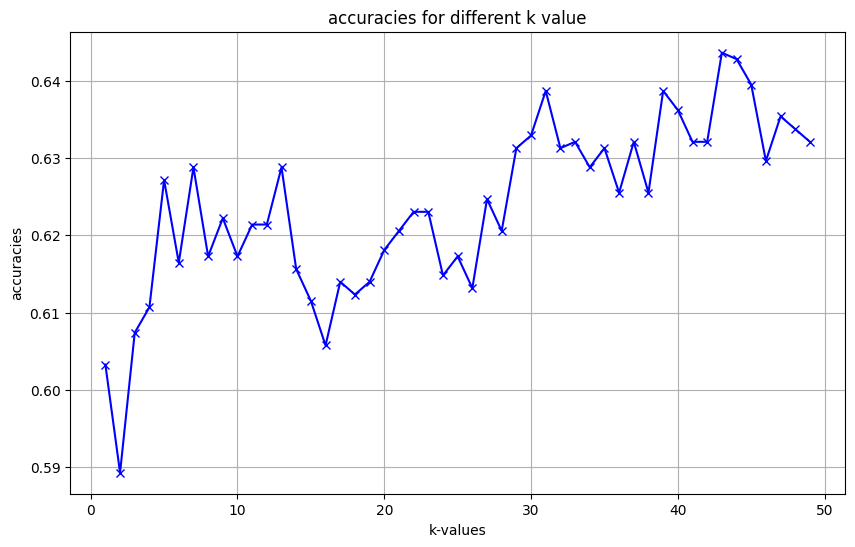

In [244]:
k_values = range(1, 50)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

# data viz
x = np.arange(1,50)
plt.figure(figsize=(10, 6))
plt.plot(x, accuracies, 'bx-')
plt.xlabel('k-values')
plt.ylabel('accuracies')
plt.title('accuracies for different k value')
plt.grid(True)
plt.show()

##### Model Performance

In [245]:
clf = KNeighborsClassifier(n_neighbors= 43)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Calculate precision
precision = precision_score(y_test, y_pred)

# Evaluate the model
print("\nAccuracy:")
print(clf.score(X_test, y_test))
print("\nPrecision Score:")
print(precision)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.6436213991769547

Precision Score:
0.6177924217462932

Confusion Matrix:
[[407 232]
 [201 375]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.64      0.65       639
           1       0.62      0.65      0.63       576

    accuracy                           0.64      1215
   macro avg       0.64      0.64      0.64      1215
weighted avg       0.64      0.64      0.64      1215



In [246]:
# target variable: review_score_rating
## high v.s. low score: scores >= 4.9
y_d = (df_drop["review_scores_rating"] >= 4.9).astype(int)

In [247]:
y_d.value_counts()

review_scores_rating
1    2568
0    2304
Name: count, dtype: int64

In [248]:
X_d = df_drop.drop(columns=["review_scores_rating"])
X_d = pd.get_dummies(X_d, drop_first = True)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

In [249]:
X_d

,relative_price,bedrooms,beds,bathrooms,accommodates,is_long_term,host_response_time,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d,room_type_Private room,room_type_Shared room,host_identity_verified_t
0,0.772909,1.0,1.0,1.0,1,1,2.0,161,0.000000,0,False,False,True
1,0.984592,1.0,2.0,3.0,2,0,1.0,220,0.063636,84,True,False,True
2,1.232497,3.0,3.0,2.0,8,1,2.0,98,0.000000,0,False,False,True
3,0.741860,1.0,2.0,1.0,4,0,1.0,1139,0.054434,255,False,False,True
4,0.969773,2.0,3.0,1.0,3,1,2.0,64,0.000000,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6004,0.770687,1.0,1.0,1.0,2,0,1.0,3,1.000000,18,False,False,True
6007,0.898058,3.0,3.0,3.5,6,0,1.0,2,1.000000,12,False,False,False
6018,1.124479,2.0,2.0,2.0,4,0,1.0,1,1.000000,6,False,False,True
6026,0.952474,1.0,2.0,1.0,3,0,1.0,3,1.000000,18,False,False,True


##### Deciding k-values (k = 43)

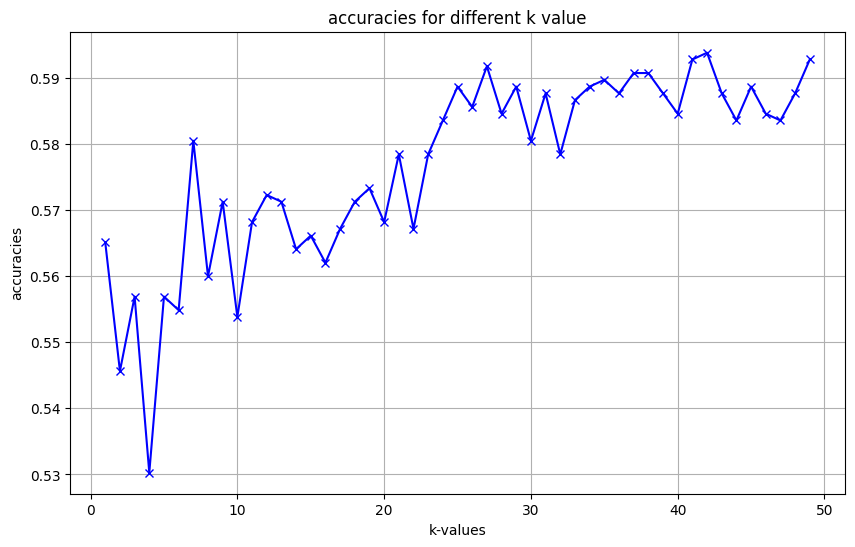

In [252]:
k_values = range(1, 50)
accuracies_d = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_d, y_train_d)
    
    y_pred_d = model.predict(X_test_d)
    acc = accuracy_score(y_test_d, y_pred_d)
    
    accuracies_d.append(acc)

# data viz
x = np.arange(1,50)
plt.figure(figsize=(10, 6))
plt.plot(x, accuracies_d, 'bx-')
plt.xlabel('k-values')
plt.ylabel('accuracies')
plt.title('accuracies for different k value')
plt.grid(True)
plt.show()

##### Model Performance

In [253]:
clf = KNeighborsClassifier(n_neighbors=43)
clf.fit(X_train_d, y_train_d)

y_pred_d = clf.predict(X_test_d)

# Calculate precision
precision_d = precision_score(y_test_d, y_pred_d)

# Evaluate the model
print("\nAccuracy:")
print(clf.score(X_test_d, y_test_d))
print("\nPrecision Score:")
print(precision_d)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_d, y_pred_d))
print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))


Accuracy:
0.5876923076923077

Precision Score:
0.5894568690095847

Confusion Matrix:
[[204 257]
 [145 369]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.44      0.50       461
           1       0.59      0.72      0.65       514

    accuracy                           0.59       975
   macro avg       0.59      0.58      0.58       975
weighted avg       0.59      0.59      0.58       975



In [355]:
sea['neighbourhood_group_cleansed'].unique()

array(['Other neighborhoods', 'Ballard', 'Cascade', 'Rainier Valley',
       'Magnolia', 'West Seattle', 'Queen Anne', 'Downtown',
       'Capitol Hill', 'Beacon Hill', 'Lake City', 'Central Area',
       'University District', 'Delridge', 'Northgate', 'Seward Park',
       'Interbay'], dtype=object)

In [348]:
def run_rf_by_area(df, area_name, target_col="review_scores_rating", min_rows=30,
                   test_size=0.2, random_state=42, plot_top_n=10):
    df = df.dropna(subset=[target_col]).copy()

    if len(df) < min_rows:
        raise ValueError(f"{area_name}: Not enough rows ({len(df)})")

    # threshold
    thres = df[target_col].quantile(0.5)

    # X, y
    X = df.drop(columns=[target_col]).copy()
    y = (df[target_col] >= thres).astype(int)

    # one-hot encoding
    X = pd.get_dummies(X, drop_first=True)

    if y.nunique() < 2:
        raise ValueError(f"{area_name}: Only one class in target")

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # model
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state
    )
    rf.fit(X_train, y_train)

    # prediction
    y_pred = rf.predict(X_test)

    # feature importance
    importance = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_features = importance.head(plot_top_n)

    # results
    result = {
        "area": area_name,
        "threshold": thres,
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "feature_importance": importance,
        "top_features": top_features,
        "model": rf
    }

    return result

In [351]:
# area list
area_dfs = [
    "Downtown",
    "Central Area",
    "Queen Anne",
    "Beacon Hill",
    "Capitol Hill",
    "West Seattle",
    "Ballard",
    "Rainier Valley",
    "Cascade",
    "Northgate",
    "University District"]

all_results = {}

for i in range(len(area_dfs)):
    try:
        tmp = sea[sea['neighbourhood_group_cleansed'] == area_dfs[i]]
        tmp = 
        result = run_rf_by_area(sea[sea['neighbourhood_group_cleansed'] == area_dfs[i]], area_dfs[i])
        all_results[area_dfs[i]] = result
        print(f"\n=== {area_dfs[i]} ===")
        print("Threshold:", result["threshold"])
        print("Accuracy:", result["accuracy"])
        print("Confusion Matrix:\n", result["confusion_matrix"])
    except Exception as e:
        print(f"\n=== {area_dfs[i]} ===")
        print("Error:", e)


=== Downtown ===
Threshold: 4.81
Accuracy: 0.8783783783783784
Confusion Matrix:
 [[59 14]
 [ 4 71]]

=== Central Area ===
Threshold: 4.88
Accuracy: 0.8706896551724138
Confusion Matrix:
 [[44 12]
 [ 3 57]]

=== Queen Anne ===
Threshold: 4.89
Accuracy: 0.9191919191919192
Confusion Matrix:
 [[44  5]
 [ 3 47]]

=== Beacon Hill ===
Threshold: 4.88
Accuracy: 0.88
Confusion Matrix:
 [[19  5]
 [ 1 25]]

=== Capitol Hill ===
Threshold: 4.85
Accuracy: 0.9
Confusion Matrix:
 [[48  6]
 [ 5 51]]

=== West Seattle ===
Threshold: 4.94
Accuracy: 0.8850574712643678
Confusion Matrix:
 [[32  8]
 [ 2 45]]

=== Ballard ===
Threshold: 4.94
Accuracy: 0.8767123287671232
Confusion Matrix:
 [[30  5]
 [ 4 34]]

=== Rainier Valley ===
Threshold: 4.88
Accuracy: 0.8939393939393939
Confusion Matrix:
 [[28  5]
 [ 2 31]]

=== Cascade ===
Threshold: 4.0
Accuracy: 0.9591836734693877
Confusion Matrix:
 [[21  2]
 [ 0 26]]

=== Northgate ===
Threshold: 4.83
Accuracy: 0.8292682926829268
Confusion Matrix:
 [[14  6]
 [ 1 20]

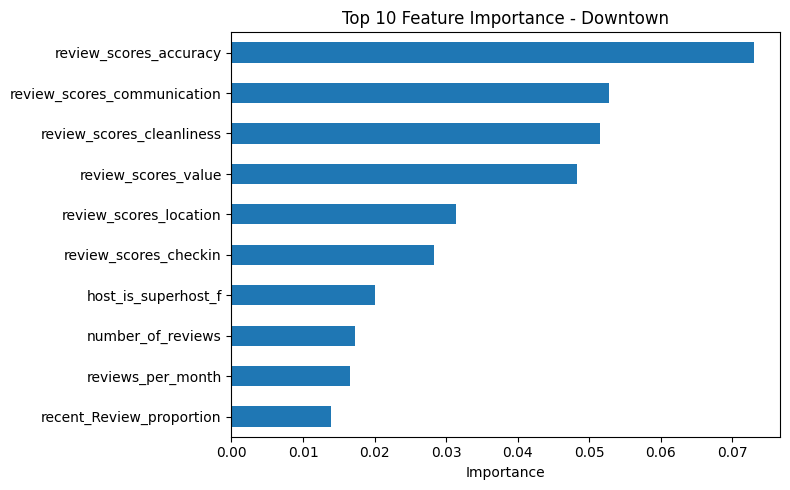

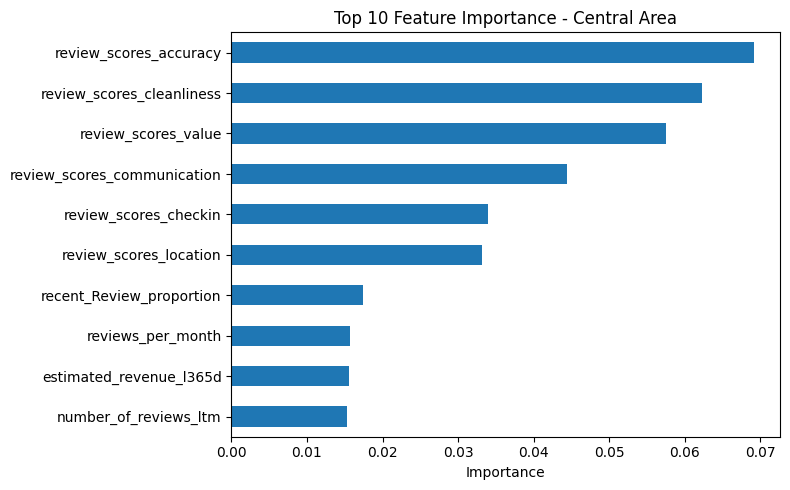

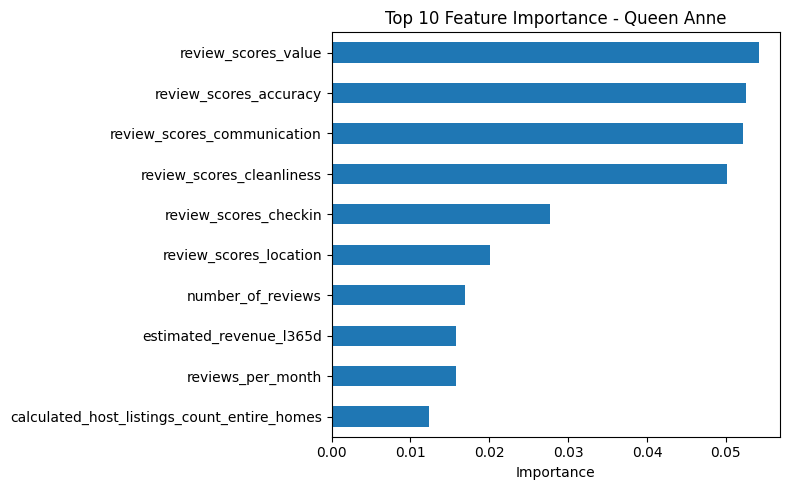

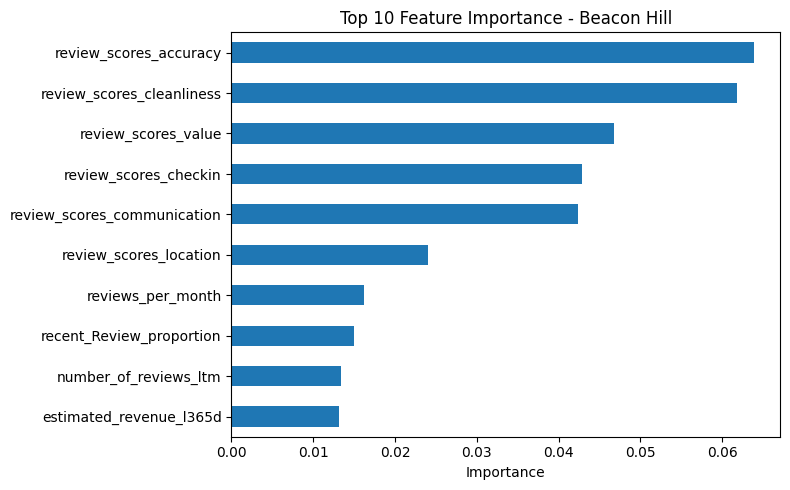

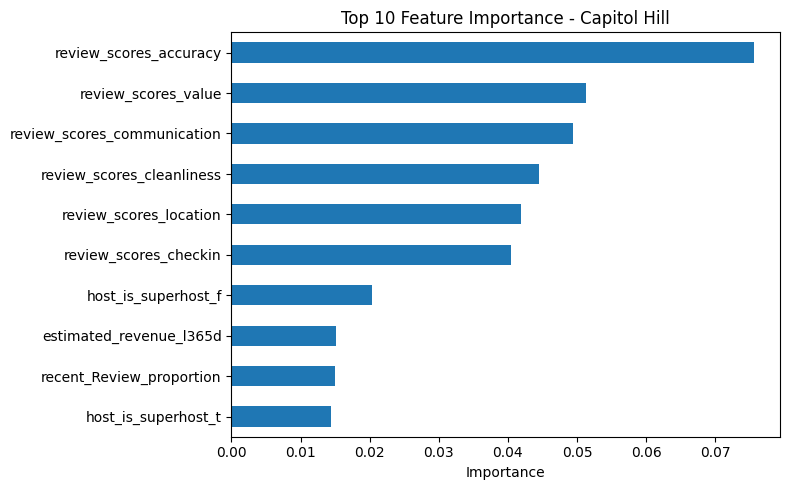

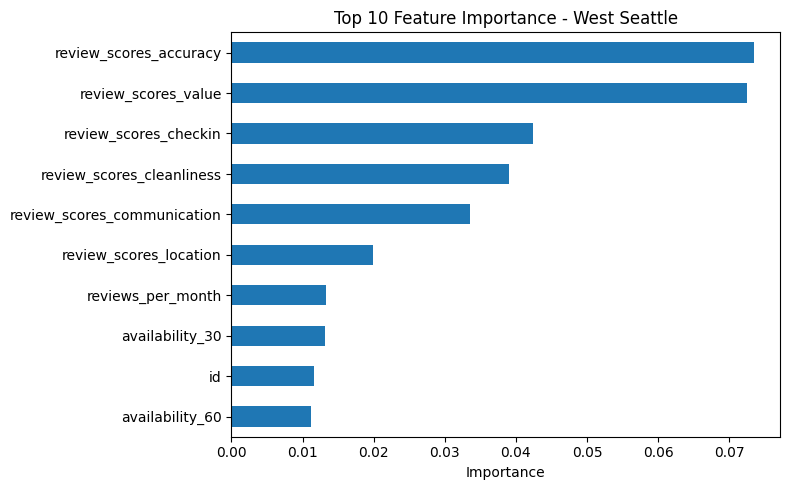

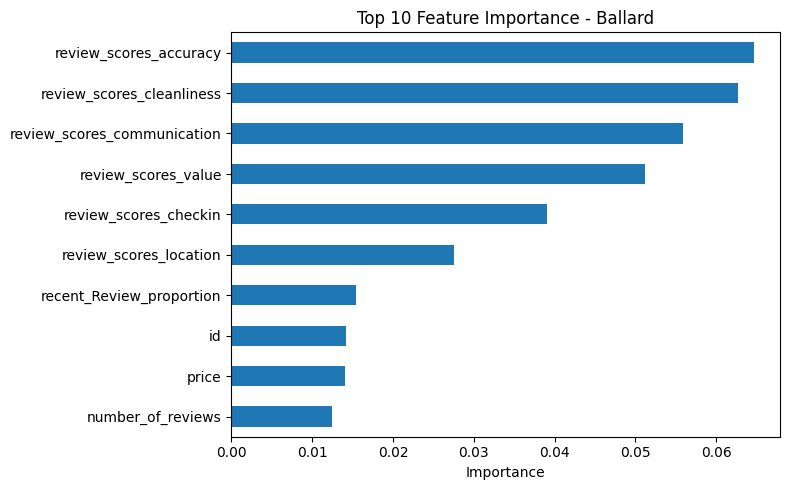

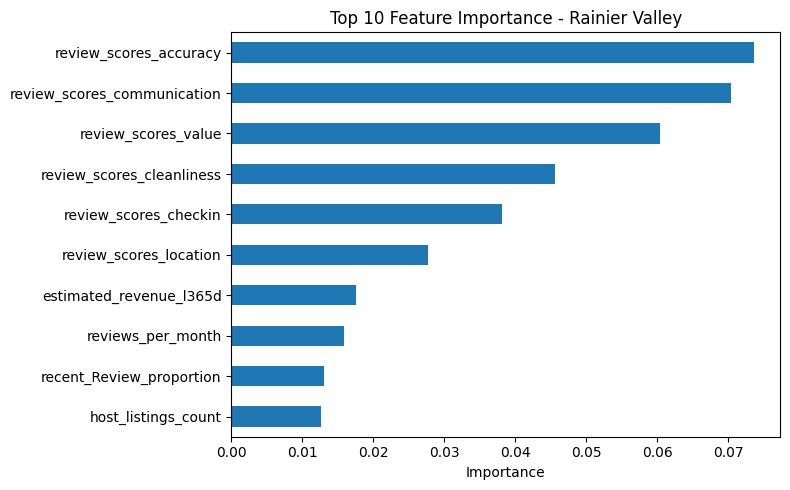

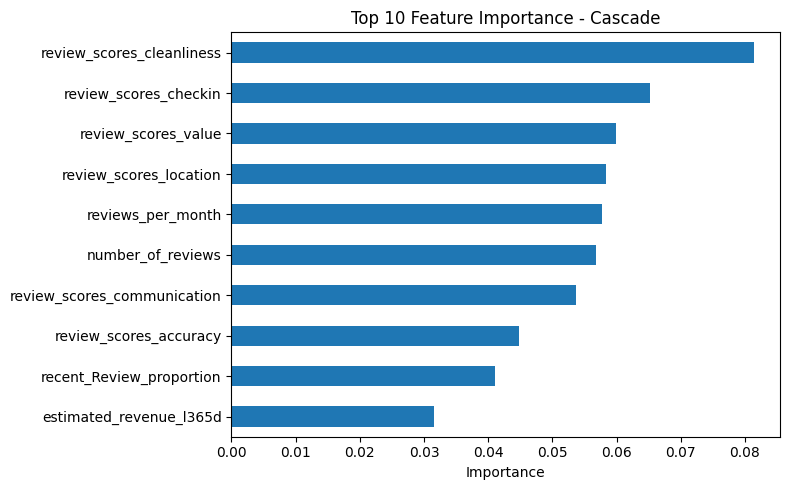

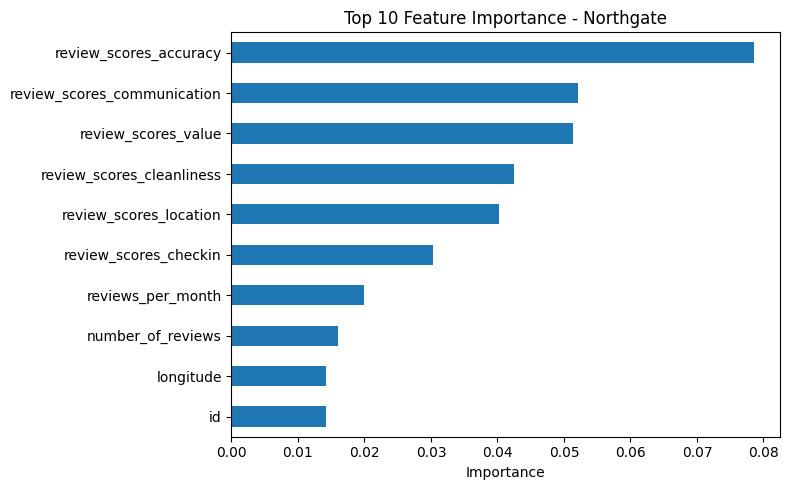

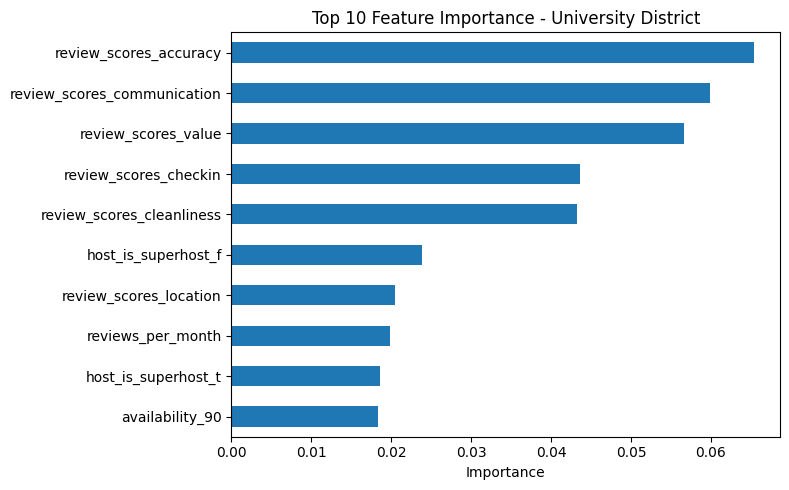

In [352]:
for area_name, result in all_results.items():
    plt.figure(figsize=(8, 5))
    result["top_features"].sort_values(ascending=True).plot(kind="barh")
    plt.title(f"Top 10 Feature Importance - {area_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [257]:
CentA = sea[sea['neighbourhood_group_cleansed']== 'Central Area']
CentA = CentA[features]
CentA.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
35,4.67,0.809160,2.0,2.0,1.0,4,Entire home/apt,0,1.0,t,371,0.048518,108
58,4.72,0.428224,1.0,1.0,1.5,2,Private room,1,1.0,t,112,0.035714,240
59,4.83,0.437956,1.0,2.0,1.5,2,Private room,1,1.0,t,110,0.036364,240
80,4.90,0.749509,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,729,0.074074,255
88,4.83,0.498767,1.0,2.0,1.0,2,Entire home/apt,1,3.0,t,263,0.019011,255


In [298]:
ca_thres = CentA['review_scores_rating'].quantile(0.5)

In [299]:
# run RF model

X_ca = CentA.drop(columns=["review_scores_rating"])
y_ca = CentA["review_scores_rating"]

X_ca = pd.get_dummies(X_ca, drop_first=True)

y_ca = (CentA["review_scores_rating"] >= ca_thres).astype(int)

X_train_ca, X_test_ca, y_train_ca, y_test_ca = train_test_split(
    X_ca, y_ca, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ca, y_train_ca)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [300]:
y_pred_ca = rf.predict(X_test_ca)

In [301]:
print("Accuracy:", accuracy_score(y_test_ca, y_pred_ca))
print(confusion_matrix(y_test_ca, y_pred_ca))
print(classification_report(y_test_ca, y_pred_ca))

Accuracy: 0.7068965517241379
[[27 20]
 [14 55]]
              precision    recall  f1-score   support

           0       0.66      0.57      0.61        47
           1       0.73      0.80      0.76        69

    accuracy                           0.71       116
   macro avg       0.70      0.69      0.69       116
weighted avg       0.70      0.71      0.70       116



In [302]:
importance_ca = pd.Series(
    rf.feature_importances_,
    index=X_train_ca.columns
).sort_values(ascending=True)

importance_ca.head(15)

host_identity_verified_f     0.009239
host_identity_verified_t     0.013751
is_long_term                 0.024369
room_type_Private room       0.027580
bathrooms                    0.036284
bedrooms                     0.038232
host_response_time           0.041634
beds                         0.052031
accommodates                 0.075782
estimated_occupancy_l365d    0.132448
relative_price               0.168575
recent_Review_proportion     0.172574
number_of_reviews            0.207501
dtype: float64

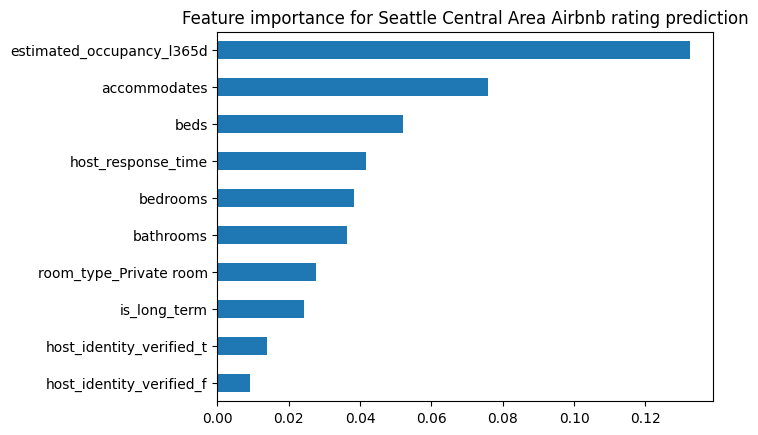

In [303]:
importance_ca.head(10).plot(kind="barh")
plt.title("Feature importance for Seattle Central Area Airbnb rating prediction")
plt.show()

In [258]:
QueenA = sea[sea['neighbourhood_group_cleansed']== 'Queen Anne']
QueenA = QueenA[features]
QueenA.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
12,4.78,1.333333,3.0,3.0,1.0,4,Entire home/apt,0,1.0,t,171,0.099415,102
47,4.91,1.147424,2.0,2.0,1.0,4,Entire home/apt,0,1.0,t,384,0.049479,114
52,4.94,1.000000,4.0,7.0,2.5,8,Entire home/apt,0,1.0,t,564,0.093972,255
72,4.88,1.122681,1.0,3.0,1.0,3,Entire home/apt,0,NaN,t,59,0.000000,0
97,4.92,0.816777,1.0,2.0,1.5,4,Entire home/apt,0,1.0,t,231,0.077922,108


In [305]:
qa_thres = QueenA['review_scores_rating'].quantile(0.5)

In [306]:
# run RF model

X_qa = QueenA.drop(columns=["review_scores_rating"])
y_qa = QueenA["review_scores_rating"]

X_qa = pd.get_dummies(X_qa, drop_first=True)

y_qa = (QueenA["review_scores_rating"] >= qa_thres).astype(int)

X_train_qa, X_test_qa, y_train_qa, y_test_qa = train_test_split(
    X_qa, y_qa, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_qa, y_train_qa)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [307]:
y_pred_qa = rf.predict(X_test_qa)

In [308]:
print("Accuracy:", accuracy_score(y_test_qa, y_pred_qa))
print(confusion_matrix(y_test_qa, y_pred_qa))
print(classification_report(y_test_qa, y_pred_qa))

Accuracy: 0.6161616161616161
[[28 24]
 [14 33]]
              precision    recall  f1-score   support

           0       0.67      0.54      0.60        52
           1       0.58      0.70      0.63        47

    accuracy                           0.62        99
   macro avg       0.62      0.62      0.62        99
weighted avg       0.63      0.62      0.61        99



In [309]:
importance_qa = pd.Series(
    rf.feature_importances_,
    index=X_train_qa.columns
).sort_values(ascending=True)

importance_qa.head(15)

host_identity_verified_f     0.007538
host_identity_verified_t     0.009137
is_long_term                 0.018095
bedrooms                     0.041165
bathrooms                    0.046305
beds                         0.058223
host_response_time           0.063047
accommodates                 0.068045
room_type_Private room       0.076322
estimated_occupancy_l365d    0.115439
recent_Review_proportion     0.135711
relative_price               0.178704
number_of_reviews            0.182270
dtype: float64

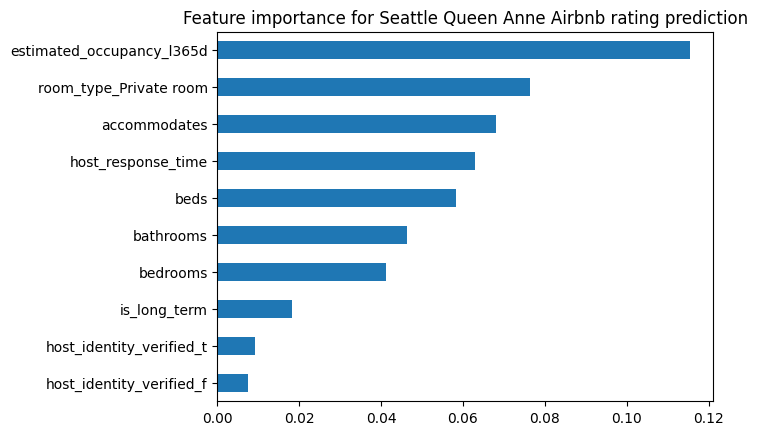

In [310]:
importance_qa.head(10).plot(kind="barh")
plt.title("Feature importance for Seattle Queen Anne Airbnb rating prediction")
plt.show()

In [260]:
BeaconH = sea[sea['neighbourhood_group_cleansed']== 'Beacon Hill']
BeaconH = BeaconH[features]
BeaconH.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
25,4.89,0.755735,1.0,1.0,1.0,2,Private room,0,2.0,t,376,0.045213,102
26,4.79,1.092735,2.0,2.0,1.0,4,Entire home/apt,1,NaN,f,203,0.000000,0
53,4.84,0.836512,1.0,1.0,1.0,2,Entire home/apt,0,2.0,t,350,0.037143,130
105,4.85,1.889339,1.0,1.0,1.0,1,Private room,1,1.0,f,13,0.153846,120
118,4.80,0.944669,1.0,1.0,1.0,2,Private room,1,3.0,f,104,0.000000,0


In [311]:
bh_thres = BeaconH['review_scores_rating'].quantile(0.5)

In [312]:
# run RF model

X_bh = BeaconH.drop(columns=["review_scores_rating"])
y_bh = BeaconH["review_scores_rating"]

X_bh = pd.get_dummies(X_bh, drop_first=True)

y_bh = (BeaconH["review_scores_rating"] >= 4.9).astype(int)

X_train_bh, X_test_bh, y_train_bh, y_test_bh = train_test_split(
    X_bh, y_bh, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_bh, y_train_bh)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [313]:
y_pred_bh = rf.predict(X_test_bh)

In [314]:
print("Accuracy:", accuracy_score(y_test_bh, y_pred_bh))
print(confusion_matrix(y_test_bh, y_pred_bh))
print(classification_report(y_test_bh, y_pred_bh))

Accuracy: 0.74
[[22  5]
 [ 8 15]]
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        27
           1       0.75      0.65      0.70        23

    accuracy                           0.74        50
   macro avg       0.74      0.73      0.73        50
weighted avg       0.74      0.74      0.74        50



In [315]:
importance_bh = pd.Series(
    rf.feature_importances_,
    index=X_train_bh.columns
).sort_values(ascending=True)

importance_bh.head(15)

host_identity_verified_t     0.016639
room_type_Private room       0.017422
is_long_term                 0.023486
bedrooms                     0.042695
host_response_time           0.043892
beds                         0.051792
bathrooms                    0.062833
accommodates                 0.087563
estimated_occupancy_l365d    0.136840
number_of_reviews            0.168068
relative_price               0.169659
recent_Review_proportion     0.179111
dtype: float64

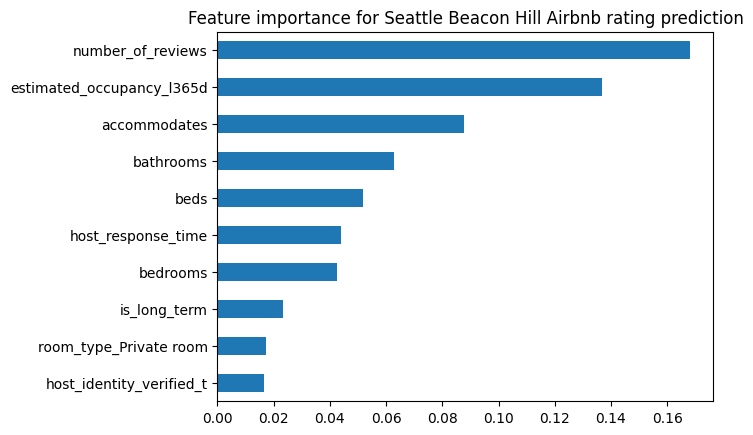

In [316]:
importance_bh.head(10).plot(kind="barh")
plt.title("Feature importance for Seattle Beacon Hill Airbnb rating prediction")
plt.show()

In [320]:
CapitolH = sea[sea['neighbourhood_group_cleansed']== 'Capitol Hill']
CapitolH = CapitolH[features]
CapitolH.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
17,4.63,1.272205,1.0,1.0,1.0,2,Entire home/apt,1,NaN,t,117,0.000,0
19,0.00,2.531471,2.0,2.0,1.0,2,Entire home/apt,1,1.0,t,0,NaN,0
21,4.90,0.671171,2.0,2.0,1.0,3,Entire home/apt,1,3.0,t,31,0.000,0
24,4.78,1.183150,1.0,1.0,1.0,2,Entire home/apt,1,1.0,t,182,0.000,0
32,4.73,0.963964,2.0,2.0,1.0,3,Entire home/apt,1,3.0,t,40,0.075,255


In [328]:
# threshold
ch_thres = CapitolH['review_scores_rating'].quantile(0.5)
# run RF model

X_ch = CapitolH.drop(columns=["review_scores_rating"])
y_ch = CapitolH["review_scores_rating"]

X_ch = pd.get_dummies(X_ch, drop_first=True)

y_ch = (CapitolH["review_scores_rating"] >= ch_thres).astype(int)

X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ch, y_train_ch)

y_pred_ch = rf.predict(X_test_ch)

print("Accuracy:", accuracy_score(y_test_ch, y_pred_ch))
print(confusion_matrix(y_test_ch, y_pred_ch))
print(classification_report(y_test_ch, y_pred_ch))

Accuracy: 0.7818181818181819
[[40 13]
 [11 46]]
              precision    recall  f1-score   support

           0       0.78      0.75      0.77        53
           1       0.78      0.81      0.79        57

    accuracy                           0.78       110
   macro avg       0.78      0.78      0.78       110
weighted avg       0.78      0.78      0.78       110



In [325]:
importance_ch = pd.Series(
    rf.feature_importances_,
    index=X_train_ch.columns
).sort_values(ascending=True)

importance_ch.head(15)

host_identity_verified_f     0.010131
host_identity_verified_t     0.013415
is_long_term                 0.022353
room_type_Private room       0.023377
host_response_time           0.034973
beds                         0.038917
bedrooms                     0.046608
bathrooms                    0.052167
accommodates                 0.056038
estimated_occupancy_l365d    0.116129
recent_Review_proportion     0.186055
relative_price               0.188109
number_of_reviews            0.211727
dtype: float64

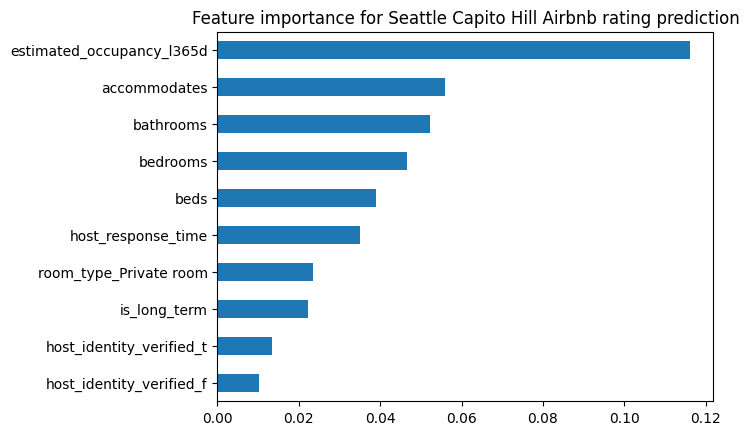

In [326]:
importance_ch.head(10).plot(kind="barh")
plt.title("Feature importance for Seattle Capito Hill Airbnb rating prediction")
plt.show()

In [330]:
WestSea = sea[sea['neighbourhood_group_cleansed']== 'West Seattle']
WestSea = WestSea[features]
WestSea.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
11,4.87,1.000000,2.0,4.0,3.0,8,Entire home/apt,0,3.0,t,39,0.282051,66
20,4.74,0.927558,1.0,1.0,1.0,4,Entire home/apt,1,2.0,t,94,0.000000,0
37,4.73,1.000000,1.0,1.0,1.0,2,Private room,1,NaN,t,22,0.000000,0
65,4.90,1.318513,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,253,0.023715,36
69,4.97,1.000000,1.0,2.0,2.0,4,Entire home/apt,0,1.0,f,546,0.065934,216


In [332]:
# threshold
ws_thres = WestSea['review_scores_rating'].quantile(0.5)

# run RF model
X_ws = WestSea.drop(columns=["review_scores_rating"])
y_ws = WestSea["review_scores_rating"]

X_ws = pd.get_dummies(X_ws, drop_first=True)

y_ws = (WestSea["review_scores_rating"] >= ws_thres).astype(int)

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_ws, y_ws, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ws, y_train_ws)

y_pred_ws = rf.predict(X_test_ws)

print("Accuracy:", accuracy_score(y_test_ws, y_pred_ws))
print(confusion_matrix(y_test_ws, y_pred_ws))
print(classification_report(y_test_ws, y_pred_ws))

Accuracy: 0.6551724137931034
[[22 19]
 [11 35]]
              precision    recall  f1-score   support

           0       0.67      0.54      0.59        41
           1       0.65      0.76      0.70        46

    accuracy                           0.66        87
   macro avg       0.66      0.65      0.65        87
weighted avg       0.66      0.66      0.65        87



In [333]:
importance_ws = pd.Series(
    rf.feature_importances_,
    index=X_train_ws.columns
).sort_values(ascending=True)

importance_ws.head(15)

room_type_Private room       0.013876
is_long_term                 0.022615
host_identity_verified_t     0.022827
host_response_time           0.033283
bedrooms                     0.039799
bathrooms                    0.045326
beds                         0.047567
accommodates                 0.062333
estimated_occupancy_l365d    0.143145
recent_Review_proportion     0.169058
number_of_reviews            0.190642
relative_price               0.209528
dtype: float64

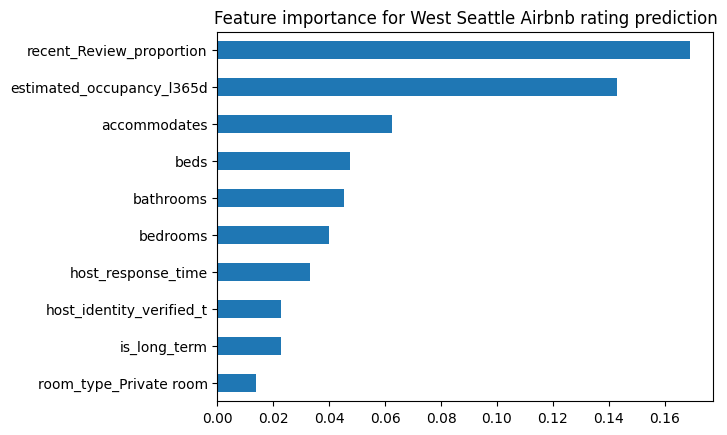

In [334]:
importance_ws.head(10).plot(kind="barh")
plt.title("Feature importance for West Seattle Airbnb rating prediction")
plt.show()

In [335]:
Ballard = sea[sea['neighbourhood_group_cleansed']== 'Ballard']
Ballard = Ballard[features]
Ballard.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
3,4.93,0.741860,1.0,2.0,1.0,4,Entire home/apt,0,1.0,t,1139,0.054434,255
14,4.91,1.003198,1.0,2.0,1.0,2,Entire home/apt,0,1.0,t,130,0.023077,18
28,4.86,0.758721,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,412,0.055825,184
61,4.92,0.798367,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,622,0.070740,255
67,4.94,0.910465,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,410,0.043902,108


In [ ]:
# threshold
ws_thres = WestSea['review_scores_rating'].quantile(0.5)

# run RF model
X_ws = WestSea.drop(columns=["review_scores_rating"])
y_ws = WestSea["review_scores_rating"]

X_ws = pd.get_dummies(X_ws, drop_first=True)

y_ws = (WestSea["review_scores_rating"] >= ws_thres).astype(int)

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_ws, y_ws, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ws, y_train_ws)

y_pred_ws = rf.predict(X_test_ws)

print("Accuracy:", accuracy_score(y_test_ws, y_pred_ws))
print(confusion_matrix(y_test_ws, y_pred_ws))
print(classification_report(y_test_ws, y_pred_ws))

In [336]:
RainierV = sea[sea['neighbourhood_group_cleansed']== 'Rainier Valley']
RainierV = RainierV[features]
RainierV.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
8,4.89,0.910967,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,419,0.000000,0
33,4.82,0.901073,1.0,1.0,1.0,2,Private room,0,1.0,t,343,0.172012,255
34,4.74,0.901073,1.0,1.0,1.0,2,Private room,0,1.0,t,370,0.048649,108
38,4.85,0.779657,1.0,1.0,1.0,2,Entire home/apt,1,NaN,t,36,0.000000,0
54,4.88,0.801906,1.0,2.0,1.0,4,Entire home/apt,0,3.0,t,239,0.075314,108


In [ ]:
# threshold
ws_thres = WestSea['review_scores_rating'].quantile(0.5)

# run RF model
X_ws = WestSea.drop(columns=["review_scores_rating"])
y_ws = WestSea["review_scores_rating"]

X_ws = pd.get_dummies(X_ws, drop_first=True)

y_ws = (WestSea["review_scores_rating"] >= ws_thres).astype(int)

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_ws, y_ws, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ws, y_train_ws)

y_pred_ws = rf.predict(X_test_ws)

print("Accuracy:", accuracy_score(y_test_ws, y_pred_ws))
print(confusion_matrix(y_test_ws, y_pred_ws))
print(classification_report(y_test_ws, y_pred_ws))

In [337]:
Cascade = sea[sea['neighbourhood_group_cleansed']== 'Cascade']
Cascade = Cascade[features]
Cascade.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
4,4.54,0.969773,2.0,3.0,1.0,3,Entire home/apt,1,2.0,t,64,0.000000,0
16,4.86,1.064232,2.0,2.0,1.0,2,Entire home/apt,1,1.0,t,14,0.142857,120
48,4.98,0.742208,1.0,1.0,1.0,2,Entire home/apt,1,1.0,t,562,0.007117,240
49,4.88,0.767510,1.0,2.0,1.0,4,Entire home/apt,1,1.0,t,148,0.027027,240
96,4.89,0.843829,2.0,2.0,1.0,4,Entire home/apt,1,1.0,t,251,0.019920,255


In [ ]:
# threshold
ws_thres = WestSea['review_scores_rating'].quantile(0.5)

# run RF model
X_ws = WestSea.drop(columns=["review_scores_rating"])
y_ws = WestSea["review_scores_rating"]

X_ws = pd.get_dummies(X_ws, drop_first=True)

y_ws = (WestSea["review_scores_rating"] >= ws_thres).astype(int)

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_ws, y_ws, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ws, y_train_ws)

y_pred_ws = rf.predict(X_test_ws)

print("Accuracy:", accuracy_score(y_test_ws, y_pred_ws))
print(confusion_matrix(y_test_ws, y_pred_ws))
print(classification_report(y_test_ws, y_pred_ws))

In [338]:
Northgate = sea[sea['neighbourhood_group_cleansed']== 'Northgate']
Northgate = Northgate[features]
Northgate.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
50,4.89,1.263666,0.0,1.0,1.0,3,Entire home/apt,0,1.0,t,202,0.014851,18
132,4.81,0.993243,1.0,1.0,1.0,2,Private room,1,2.0,t,96,0.000000,0
257,4.95,1.184615,1.0,1.0,1.0,2,Entire home/apt,0,1.0,t,281,0.049822,84
340,4.88,0.655949,0.0,1.0,1.0,1,Entire home/apt,1,3.0,t,142,0.007042,60
347,4.97,1.015385,1.0,1.0,1.0,2,Entire home/apt,1,3.0,f,184,0.021739,240


In [ ]:
# threshold
ws_thres = WestSea['review_scores_rating'].quantile(0.5)

# run RF model
X_ws = WestSea.drop(columns=["review_scores_rating"])
y_ws = WestSea["review_scores_rating"]

X_ws = pd.get_dummies(X_ws, drop_first=True)

y_ws = (WestSea["review_scores_rating"] >= ws_thres).astype(int)

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_ws, y_ws, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ws, y_train_ws)

y_pred_ws = rf.predict(X_test_ws)

print("Accuracy:", accuracy_score(y_test_ws, y_pred_ws))
print(confusion_matrix(y_test_ws, y_pred_ws))
print(classification_report(y_test_ws, y_pred_ws))

In [339]:
UD = sea[sea['neighbourhood_group_cleansed']== 'University District']
UD = UD[features]
UD.head()

,review_scores_rating,relative_price,bedrooms,beds,bathrooms,accommodates,room_type,is_long_term,host_response_time,host_identity_verified,number_of_reviews,recent_Review_proportion,estimated_occupancy_l365d
40,4.20,0.868217,1.0,2.0,1.0,3,Entire home/apt,1,1.0,t,40,0.000000,0
74,4.03,0.877076,1.0,1.0,1.0,3,Entire home/apt,1,1.0,t,37,0.000000,0
78,4.95,1.103542,3.0,4.0,1.5,7,Entire home/apt,1,NaN,t,19,0.000000,0
86,4.13,0.926380,2.0,3.0,2.0,5,Entire home/apt,1,1.0,t,30,0.000000,0
91,4.05,1.001107,1.0,1.0,1.0,3,Entire home/apt,1,1.0,t,39,0.051282,120


In [ ]:
# threshold
ws_thres = WestSea['review_scores_rating'].quantile(0.5)

# run RF model
X_ws = WestSea.drop(columns=["review_scores_rating"])
y_ws = WestSea["review_scores_rating"]

X_ws = pd.get_dummies(X_ws, drop_first=True)

y_ws = (WestSea["review_scores_rating"] >= ws_thres).astype(int)

X_train_ws, X_test_ws, y_train_ws, y_test_ws = train_test_split(
    X_ws, y_ws, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_ws, y_train_ws)

y_pred_ws = rf.predict(X_test_ws)

print("Accuracy:", accuracy_score(y_test_ws, y_pred_ws))
print(confusion_matrix(y_test_ws, y_pred_ws))
print(classification_report(y_test_ws, y_pred_ws))

In [96]:
# Calculate permutation importance
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)

# result.importances_mean contains the importance scores
importances = pd.DataFrame({
    "feature_names": X.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending = False)
importances.head(10)

,feature_names,Importance
5,minimum_nights,0.096753
4,accommodates,0.033929
2,beds,0.024269
3,bathrooms,0.022646
6,neighbourhood_Neighborhood highlights,0.018425
1,bedrooms,0.017532
7,room_type_Private room,0.015909
0,relative_price,0.013961
12,host_response_time_within an hour,0.012825
11,host_response_time_within a few hours,0.002110


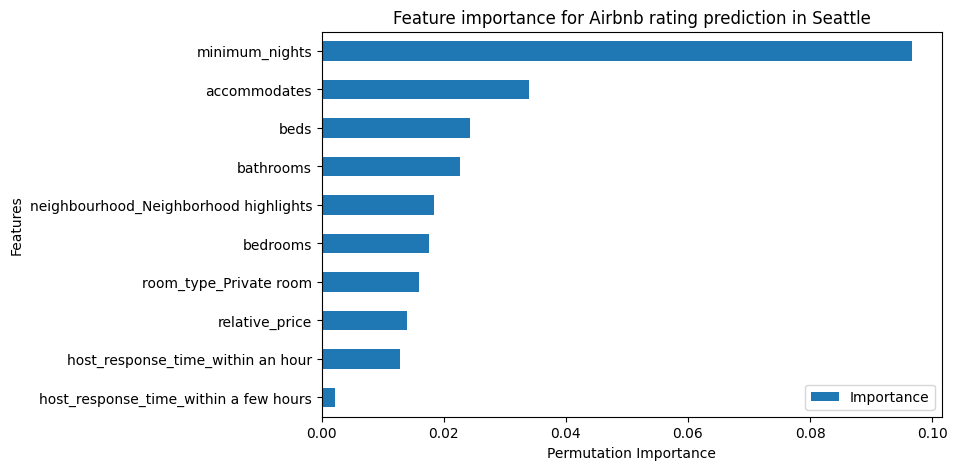

In [97]:
# data viz
importances.head(10).plot(
    x="feature_names",
    y="Importance",
    kind="barh",
    figsize=(8, 5)
)
plt.title("Feature importance for Airbnb rating prediction in Seattle")
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

np.float64(99.0)